# 1.6 最近傍法（1/2）: 近傍の探索・分類・回帰

**原典**: scikit-learn User Guide [1.6. Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html)（v1.9.1）の 1.6.1〜1.6.3

| | |
|---|---|
| **このノートで分かるようになること** | ・最近傍法が「学習データを覚えておき、近いものを探して答える」方法であることを説明できる<br>・`NearestNeighbors` で近傍を探し、近傍グラフを作れる<br>・`KNeighborsClassifier` / `KNeighborsRegressor` の `n_neighbors` と `weights` が、学習したモデル（決定境界・予測の曲線）をどう変えるか、図で説明できる<br>・半径ベースの近傍法、次元の呪い、スケーリングの必要性など、最近傍法の落とし穴が分かる |
| **前提** | [1.1 線形モデル（1/4）](./01_linear_models_1_ols_regularization.ipynb)（`fit` / `predict` の使い方）。数学は「2 点間の距離」が分かれば十分です |
| **目安時間** | 60〜90 分 |

### 🗺️ 3 行でいうと

1. **最近傍法**は、学習データを覚えておき、新しい点に**いちばん近い k 件**を探して、多数決（分類）や平均（回帰）で答える。不動産屋が「似た物件を 5 件探して、その家賃の平均を相場にする」のと同じやり方。
2. `n_neighbors`（何件見るか）が小さいほど境界はギザギザ（過学習しやすい）、大きいほどなめらか。`weights="distance"` は近い点ほど重く見る。
3. 「近さ」は距離で決まるので、**標準化が必須**。特徴が多すぎる・関係のない特徴が多いと弱い（次元の呪い）。

> 📐 **数式について**: 本文の式は、記号の表（🔢）と「日本語で読むと」で読めるようにしています。式を**もっと詳しく**（小さな数値で計算してみる・なぜこの形になるのか）知りたい人は、各所のリンクから [数式編](./math/06_neighbors_1_knn_math.md) へ。中学で習う範囲から必要な数学の道具は [数学の準備](../00_math_primer.md)、用語は [用語集](../glossary.md) にまとめています。

### このノートの読み方

| 記号 | 意味 |
|---|---|
| 📖 **ガイドの解説** | 公式ガイドの内容を日本語で説明したもの |
| 💡 **補足** | 初学者向けに、ガイドにない前提知識・直感・たとえ話を足したもの |
| 📚 **用語** / 🔢 **数式を読む** | 初出の用語の説明 / 数式の記号を 1 つずつ説明し、日本語で読み下したもの |
| 🎯 **なぜ使うのか** / 🏭 **利用例** / 🕰️ **歴史** | 手法が使われる理由・実際の応用・生まれた経緯（参考情報） |
| 🧪 **やってみよう** / 📈 **学習したモデルを見る** / 👀 **結果の読み方** | コードで確かめる / 学習したモデルを図で確かめる / 出力のどこを見ればよいか |
| ⚠️ **つまずきポイント** | 実際に動かして分かった落とし穴（ガイドに書かれていないものを含む） |
| 🏢 **実務での選ばれ方** | 実際の業務で、その手法が選ばれる場面・選ばれない場面・よく組み合わせる手法 |
| 📐 **もっと詳しく（数式編）** | 本文の式を、数値の例・導き方・図の読み方まで含めて、さらに詳しく説明した別ファイルへのリンク |

### 目次

0. 導入: 最近傍法とは（距離の測り方）
1. 1.6.1 教師なしの最近傍（近傍の探索、近傍グラフ、`KDTree` / `BallTree`）
2. 1.6.2 最近傍法による分類（`n_neighbors`、`weights`、半径ベース、次元の呪い）
3. 1.6.3 最近傍法による回帰
4. まとめ・確認クイズ

探索アルゴリズムの中身（1.6.4）、最近傍重心法（1.6.5）、近傍の Transformer（1.6.6）、NCA（1.6.7）は [2/2](./06_neighbors_2_algorithms_nca.ipynb) で扱います。

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は、上から順に実行してください。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

from sklearn import neighbors as nbr
from sklearn.datasets import make_moons, load_wine
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def plot_boundary(ax, model, X, y, title, h=0.02, proba=True):
    # 学習したモデルの決定境界（背景の色）とデータ点を描く
    x0, x1 = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y0, y1 = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x0, x1, h), np.arange(y0, y1, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid)[:, 1] if proba else model.predict(grid)
    ax.contourf(xx, yy, Z.reshape(xx.shape), levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=0.5)
    ax.contour(xx, yy, Z.reshape(xx.shape), levels=[0.5], colors="k", linewidths=1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolor="k", s=15)
    ax.set_title(title, fontsize=9); ax.grid(False)

---
## 0. 導入: 最近傍法とは

### 📖 ガイドの解説

`sklearn.neighbors` は、教師なし・教師ありの、近傍に基づく学習法の機能を提供します。教師なしの最近傍法は、ほかの多くの学習法、特に**多様体学習**や**スペクトラルクラスタリング**の土台になっています。教師ありの近傍法には 2 種類あり、離散的なラベルのデータには**分類**、連続的なラベルのデータには**回帰**を使います。

最近傍法の原理は、新しい点に**距離が最も近い**学習サンプルを決まった数だけ探し、それらからラベルを予測することです。サンプルの数は、ユーザーが決めた定数（**k 近傍法**）にすることも、点の局所的な密度に応じて変えること（**半径ベースの近傍法**）もできます。距離は一般にどんな距離（metric）でもよく、標準的な**ユークリッド距離**が最もよく使われます。

近傍法は、**汎化しない（non-generalizing）**機械学習の方法と呼ばれます。学習データをすべて「覚えておく」だけだからです（`BallTree` や `KDTree` のような高速な索引の構造に変換することはあります）。

単純なのに、最近傍法は、手書き数字や衛星画像のシーンなど、多くの分類・回帰の問題で成功しています。**ノンパラメトリック**な方法なので、決定境界がとても不規則な分類でうまくいくことがよくあります。

`sklearn.neighbors` のクラスは、NumPy 配列と `scipy.sparse` 行列のどちらも入力にできます。密な行列では多くの距離が使えます。疎な行列では、任意のミンコフスキー距離で探索できます。

最近傍法を中心に使う学習法はたくさんあります。たとえば**カーネル密度推定**で、これは密度推定の節（2.8）で説明します。

> 📚 **用語**
> - **ノンパラメトリック（non-parametric）** — モデルの形（パラメータの数）を前もって決めない方法。線形モデルは「係数 $p$ 個」と形が決まっている（パラメトリック）が、最近傍法はデータが増えるほど「覚えるもの」も増える。
> - **インスタンスベース学習 / 怠惰学習（lazy learning）** — 学習のときには何もせず（データを覚えるだけ）、予測のときに初めて計算する方法。逆に、学習のときにモデルを作り込む方法（線形モデルや SVM）は**熱心な学習（eager learning）**と呼ばれる。
> - **多様体学習 / スペクトラルクラスタリング** — 高次元のデータの「近所づきあい」をもとに、低次元に埋め込んだり（2.2 節）、グループに分けたり（2.3 節）する方法。どちらも近傍の情報を土台にする。

### 💡 補足: たとえ話 — 「似た物件の相場」で家賃を見積もる不動産屋

新しい物件の家賃を見積もる不動産屋を想像してください。式を作る代わりに、過去の物件の台帳から、**駅からの距離・広さ・築年数が似ている物件を 5 件探し**、その家賃の平均を答えます。これが k 近傍法（k = 5）の回帰です。

- 「台帳を覚えておく」のが `fit`、「似た物件を探して平均する」のが `predict` です。
- 「似ている」をどう測るか（距離）、何件見るか（k）、近い物件ほど重く見るか（重み）が、モデルの設計そのものです。
- 「広さ（㎡）」と「築年数（年）」を同じ物差しで比べると、単位の大きい特徴ばかりが効いてしまいます。これが 2 章で見る**スケーリングの必要性**です。

🎯 **なぜ使うのか（参考情報）**: 仮定がほとんどなく（線形や正規分布を仮定しない）、説明が簡単（「この 5 件と似ているから」）で、データを追加するだけで更新できます。また「似たものを探す」こと自体が目的になる場面（推薦、検索）では、そのまま使えます。

🏭 **利用例（参考情報）**: 「この商品を買った人はこんな商品も」型の推薦、画像や文章の類似検索（ベクトル検索）、欠損値の補完（`KNNImputer`、6.4 節）、異常検知（近くに仲間がいない点を異常とみなす、2.7 節の `LocalOutlierFactor`）。

🕰️ **歴史（参考情報）**: 最近傍による分類は、1951 年に Fix と Hodges が米空軍の技術報告でノンパラメトリックな判別法として提案したのが始まりとされます。1967 年に Cover と Hart が、データが無限に多いとき 1-最近傍法の誤り率は、理論上最良の誤り率（ベイズ誤り率）の **2 倍以下**になることを示し、「単純なのに理論的にも悪くない」方法として定着しました。

### 🔢 数式を読む: 距離の測り方

2 つの点 $x = (x_1, \dots, x_D)$ と $z = (z_1, \dots, z_D)$ の距離として、よく使うものは次のとおりです。

| 名前 | 式 | scikit-learn の指定 |
|---|---|---|
| ユークリッド距離 | $d(x, z) = \sqrt{\sum_{j=1}^{D} (x_j - z_j)^2}$ | `metric="euclidean"`（既定は `"minkowski"`, `p=2` で同じ） |
| マンハッタン距離 | $d(x, z) = \sum_{j=1}^{D} \lvert x_j - z_j \rvert$ | `metric="manhattan"`、または `p=1` |
| ミンコフスキー距離 | $d(x, z) = \left( \sum_{j=1}^{D} \lvert x_j - z_j \rvert^p \right)^{1/p}$ | `metric="minkowski", p=...` |
| チェビシェフ距離 | $d(x, z) = \max_j \lvert x_j - z_j \rvert$ | `metric="chebyshev"`（$p \to \infty$ の極限） |

| 記号 | 意味 |
|---|---|
| $D$ | 特徴の数（次元）。ガイドの 1.6.4 では $D$、ほかの節では $p$ や `n_features` と書かれる |
| $x_j - z_j$ | 特徴 $j$ についての 2 点の差 |
| $p$ | ミンコフスキー距離の次数。1 ならマンハッタン、2 ならユークリッド |

**日本語で読むと**: ユークリッド距離は「定規で測ったまっすぐな距離」、マンハッタン距離は「碁盤の目の街を、縦と横にしか歩けないときの道のり」、チェビシェフ距離は「一番差の大きい特徴の差」。

> 📐 **もっと詳しく**: [数式編「距離の式」](./math/06_neighbors_1_knn_math.md#dist)（数値の例・導き方つき）

#### 📈 距離ごとの「距離 1 の点の集まり」

原点からの距離がちょうど 1 になる点を描くと、距離の性格が見えます。

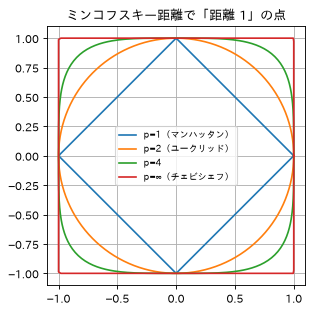

In [2]:
t = np.linspace(0, 2 * np.pi, 400)
plt.figure(figsize=(4.4, 4.2))
for p_, label in [(1, "p=1（マンハッタン）"), (2, "p=2（ユークリッド）"), (4, "p=4"), (np.inf, "p=∞（チェビシェフ）")]:
    u = np.c_[np.cos(t), np.sin(t)]
    norm = np.abs(u).max(1) if p_ == np.inf else (np.abs(u) ** p_).sum(1) ** (1 / p_)
    v = u / norm[:, None]                                # 方向 u に沿って、距離がちょうど 1 になる点
    plt.plot(v[:, 0], v[:, 1], label=label)
plt.gca().set_aspect("equal"); plt.legend(fontsize=8, loc="center"); plt.title("ミンコフスキー距離で「距離 1」の点")
plt.show()

👀 $p = 1$ はひし形、$p = 2$ は円、$p$ が大きくなるほど正方形に近づき、$p = \infty$ で正方形になります。どの距離を使うかで「近い」の意味が変わり、選ばれる近傍も変わります（1.5 の正則化の等高線と同じ形なのは、どちらもノルムの等高線だからです）。

### 🧪 やってみよう: k 近傍法を自分で書いて、scikit-learn と比べる

「距離を全部計算して、近い順に k 個とって多数決」を、NumPy で数行で書きます。

In [3]:
def my_knn_predict(X_train, y_train, X_query, k):
    d = np.sqrt(((X_query[:, None, :] - X_train[None, :, :]) ** 2).sum(-1))   # すべての組の距離
    idx = np.argsort(d, axis=1, kind="stable")[:, :k]                          # 近い順に k 個
    return np.array([np.bincount(y_train[row]).argmax() for row in idx])       # 多数決

Xm, ym = make_moons(200, noise=0.3, random_state=0)
Xq = np.random.RandomState(1).uniform(-1.5, 2.5, (500, 2))
mine = my_knn_predict(Xm, ym, Xq, k=7)
sk = nbr.KNeighborsClassifier(n_neighbors=7).fit(Xm, ym).predict(Xq)
print("500 点の予測が一致した割合:", (mine == sk).mean())

500 点の予測が一致した割合: 1.0


👀 自分で書いた数行と `KNeighborsClassifier` の予測が、500 点すべてで一致しました。最近傍法の中身は本当にこれだけです。scikit-learn の価値は、この「距離を全部計算する」部分を、木構造などで速くしている点にあります（2/2 の 1.6.4）。

### 📖 ⚠️ ガイドの警告: 同じ距離の近傍

最近傍のアルゴリズムでは、$k$ 番目と $k+1$ 番目の近傍が**同じ距離**で、ラベルが違う場合、結果は**学習データの並び順**に依存します。

In [4]:
X_tie = np.array([[1.0], [-1.0]])        # 原点から同じ距離 1 にある 2 点
y_tie = np.array([0, 1])
for order in [[0, 1], [1, 0]]:
    m = nbr.KNeighborsClassifier(n_neighbors=1).fit(X_tie[order], y_tie[order])
    print(f"学習データの並び {X_tie[order].ravel()} / ラベル {y_tie[order]} → 原点の予測: {m.predict([[0.0]])}")

学習データの並び [ 1. -1.] / ラベル [0 1] → 原点の予測: [0]
学習データの並び [-1.  1.] / ラベル [1 0] → 原点の予測: [1]


👀 同じデータ・同じモデルなのに、学習データの並び順を変えただけで、原点の予測が 0 から 1 に変わりました。同じ距離なら、先に並んでいる点が「近傍」に選ばれるからです。整数値の特徴（年齢、個数など）では同じ距離がよく起こるので、結果を再現したいときは、データの並び順も固定しておく必要があります。

---
## 1. 教師なしの最近傍（1.6.1 Unsupervised Nearest Neighbors）

### 📖 ガイドの解説

`NearestNeighbors` は、教師なしの最近傍の学習を実装しています。これは、3 つの異なる最近傍アルゴリズム、`BallTree`、`KDTree`、`sklearn.metrics.pairwise` の関数による**総当たり（brute-force）**のアルゴリズムへの、**統一された窓口**として働きます。どのアルゴリズムを使うかは引数 `algorithm` で指定し、`['auto', 'ball_tree', 'kd_tree', 'brute']` のどれかにします。既定値の `'auto'` では、学習データから最もよい方法を自動で選びます。それぞれの長所と短所は、1.6.4（2/2）で説明します。

> 📚 **用語**: **教師なし（unsupervised）の最近傍** — ラベルを使わず、「どの点がどの点に近いか」を調べるだけの処理。予測はしないが、クラスタリングや可視化、推薦などの部品になる。

### 1.6.1.1 最近傍を探す

2 つのデータの集まりの間で最近傍を探す、という単純な作業には、`sklearn.neighbors` の教師なしのアルゴリズムが使えます（ガイドの例）。

In [5]:
X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
nbrs = nbr.NearestNeighbors(n_neighbors=2, algorithm="ball_tree").fit(X)
distances, indices = nbrs.kneighbors(X)
print("indices =\n", indices)
print("distances =\n", distances)

indices =
 [[0 1]
 [1 0]
 [2 1]
 [3 4]
 [4 3]
 [5 4]]
distances =
 [[0.     1.    ]
 [0.     1.    ]
 [0.     1.4142]
 [0.     1.    ]
 [0.     1.    ]
 [0.     1.4142]]


👀 ガイドと同じ出力です。問い合わせる点の集まりが学習データと同じなので、各点の最近傍は**その点自身**で、距離は 0 です（1 列目）。2 列目が「自分以外で一番近い点」です。

> ⚠️ **つまずきポイント（ガイドのこの節には書かれていない）**: 「自分自身を除いた近傍」がほしいときは、`kneighbors()` を**引数なしで**呼びます。学習データのそれぞれの点について、自分自身を除いた近傍を返します。

In [6]:
d0, i0 = nbrs.kneighbors()        # X を渡さない
print("自分を除いた近傍 indices =\n", i0)

自分を除いた近傍 indices =
 [[1 2]
 [0 2]
 [1 0]
 [4 5]
 [3 5]
 [4 3]]


👀 今度は 1 列目に自分自身が出てきません。点 2（$[-3, -2]$）の近傍は点 1 と点 0 です。`kneighbors(X)` で 2 列目以降をとる方法でも似た結果になりますが、同じ座標の点が重複しているデータでは「自分」が 1 列目に来るとは限らないので、引数なしの呼び方のほうが安全です。

### 📖 近傍グラフ

近傍どうしのつながりを表す**疎なグラフ**も、効率よく作れます。

In [7]:
nbrs.kneighbors_graph(X).toarray()

array([[1., 1., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0.],
       [0., 0., 0., 1., 1., 0.],
       [0., 0., 0., 0., 1., 1.]])

📖 このデータは、添字の順番が近い点が、空間の中でも近くにあるように作られているので、k 近傍の行列はおおよそ**ブロック対角**になります。このような疎なグラフは、点どうしの空間的な関係を使う教師なし学習のさまざまな場面で役に立ちます。特に `Isomap`、`LocallyLinearEmbedding`、`SpectralClustering` を参照してください。

> 📚 **用語**
> - **近傍グラフ（k-nearest neighbors graph）** — 点を頂点とし、各点からその k 個の近傍に辺を張ったグラフ。行列で表すと、行 $i$・列 $j$ が「点 $j$ は点 $i$ の近傍か」（1 か 0）になる。各行に k 個しか 1 がないので、ほとんどが 0 の**疎な行列**になる。
> - **ブロック対角** — 行列の対角線に沿って、正方形の塊（ブロック）にだけ 0 でない値があり、それ以外が 0 の形。ここでは「点 0〜2 のグループ」と「点 3〜5 のグループ」の 2 つの塊。

#### 📈 近傍グラフを図で見る

2 次元のデータ（100 点）で、各点からその 5 つの近傍へ線を引きます。

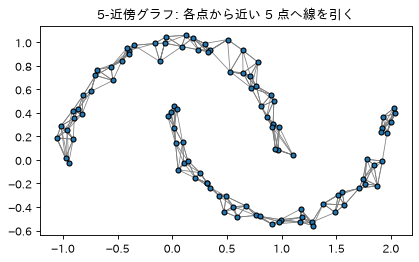

グラフの形: (100, 100) / 0 でない要素の数: 600 （= 100 点 × 6、自分自身を含む）


In [8]:
Xg, _ = make_moons(100, noise=0.06, random_state=0)
G = nbr.NearestNeighbors(n_neighbors=6).fit(Xg).kneighbors_graph(Xg)   # 自分自身 + 5 個
rows, cols = G.nonzero()
plt.figure(figsize=(6, 3.4))
for i, j in zip(rows, cols):
    if i != j:
        plt.plot(Xg[[i, j], 0], Xg[[i, j], 1], c="gray", lw=0.7, zorder=1)
plt.scatter(Xg[:, 0], Xg[:, 1], s=20, c="tab:blue", edgecolor="k", zorder=2)
plt.title("5-近傍グラフ: 各点から近い 5 点へ線を引く"); plt.grid(False); plt.show()
print("グラフの形:", G.shape, "/ 0 でない要素の数:", G.nnz, "（= 100 点 × 6、自分自身を含む）")

👀 線は、それぞれの三日月の**中だけ**でつながり、2 つの三日月の間にはほとんど線が張られていません。ユークリッド距離では「左の三日月の端」と「右の三日月の端」が近く見えても、近傍グラフをたどると別の塊だと分かります。スペクトラルクラスタリングや Isomap は、この「グラフの上での近さ」を使って、曲がった形のデータを扱います（2 章）。

### 1.6.1.2 `KDTree` と `BallTree` のクラス

`KDTree` や `BallTree` のクラスを直接使って、最近傍を探すこともできます。これは、上で使った `NearestNeighbors` が内部で包んでいる機能です。Ball Tree と KD Tree は同じ使い方（インターフェース）なので、ここでは KD Tree の例を示します（ガイドの例）。

In [9]:
kdt = nbr.KDTree(X, leaf_size=30, metric="euclidean")
print(kdt.query(X, k=2, return_distance=False))
print("KDTree.valid_metrics  :", nbr.KDTree.valid_metrics)
print("BallTree.valid_metrics:", nbr.BallTree.valid_metrics)

[[0 1]
 [1 0]
 [2 1]
 [3 4]
 [4 3]
 [5 4]]
KDTree.valid_metrics  : ['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity']
BallTree.valid_metrics: ['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity', 'seuclidean', 'mahalanobis', 'hamming', 'canberra', 'braycurtis', 'jaccard', 'dice', 'rogerstanimoto', 'russellrao', 'sokalmichener', 'sokalsneath', 'haversine', 'pyfunc']


### 🏢 実務での選ばれ方: 近傍の探索（`NearestNeighbors` / `KDTree` / `BallTree`）

- ✅ **特に選ばれる場面**: 「似ているものを探す」こと自体が目的のとき（似た商品・似た文書・似た画像の検索、推薦）。クラスタリングや可視化（DBSCAN、Isomap、t-SNE）の部品として、近傍グラフを作るとき。
- ❌ **選ばれない場面**: データが数百万件を超える、または次元が数百を超える（正確な探索は遅い）→ 近似最近傍探索。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: 今の類似検索は「深層学習で作った埋め込みベクトル（文章・画像）+ 近似最近傍探索（Faiss、HNSW、ScaNN など）」が定番です。scikit-learn の `NearestNeighbors` は、数万件くらいまでの試作や、`KNeighborsTransformer`（2/2）で近傍グラフを作る用途で使われます。

📖 探索の方法や距離の指定など、使える選択肢の詳細は `KDTree` と `BallTree` のクラスのドキュメントを参照してください。使える距離の一覧は `KDTree.valid_metrics` と `BallTree.valid_metrics` で確かめられます。

👀 KD Tree は、座標軸に沿った距離（ユークリッド、マンハッタン、チェビシェフ、ミンコフスキー）にしか対応していません。Ball Tree は、マハラノビス距離、ハミング距離、緯度経度の球面上の距離（`haversine`）、自分で定義した関数（`pyfunc`）など、ずっと多くの距離に対応しています。なぜそうなるかは、2 つの木の作り方の違い（2/2 の 1.6.4）から分かります。

---
## 2. 最近傍法による分類（1.6.2 Nearest Neighbors Classification）

### 📖 ガイドの解説

近傍に基づく分類は、**インスタンスベース学習**、あるいは**汎化しない学習**の一種です。一般的な内部モデルを作ろうとはせず、学習データのインスタンスをそのまま保存するだけです。分類は、各点の最近傍による**単純な多数決**で計算します。問い合わせた点には、その最近傍の中で最も多いクラスが割り当てられます。

scikit-learn には 2 種類の最近傍の分類器があります。

| クラス | 近傍の決め方 | 引数 |
|---|---|---|
| `KNeighborsClassifier` | 各問い合わせ点の $k$ 個の最近傍 | $k$（整数、`n_neighbors`） |
| `RadiusNeighborsClassifier` | 各問い合わせ点から固定の半径 $r$ の内側にある近傍 | $r$（小数、`radius`） |

`KNeighborsClassifier` の $k$ 近傍法が最もよく使われます。最適な $k$ の値は**データに強く依存**します。一般に、$k$ を大きくするとノイズの影響が抑えられますが、分類の境界がはっきりしなくなります。

### 🔢 数式を読む: 多数決と重み付き多数決

$$\hat{y}(x) = \underset{c}{\arg\max} \sum_{i \in N_k(x)} w_i \, \mathbb{1}[y_i = c]$$

| 記号 | 意味 |
|---|---|
| $\hat{y}(x)$ | 点 $x$ の予測クラス |
| $N_k(x)$ | $x$ に最も近い $k$ 個の学習サンプルの番号の集まり |
| $\mathbb{1}[y_i = c]$ | 学習サンプル $i$ のラベルが $c$ なら 1、そうでなければ 0（指示関数） |
| $w_i$ | 近傍 $i$ の票の重み。`weights="uniform"` なら全員 1、`weights="distance"` なら $1 / d(x, x_i)$ |
| $\arg\max_c$ | 右の値（得票）が最大になるクラス $c$ |

**日本語で読むと**: $x$ に近い $k$ 人に「あなたのクラスは？」と聞き、クラスごとに票（重み）を合計して、一番多く票を集めたクラスを答える。

`predict_proba` は、クラス $c$ の得票を全体の得票で割った値 $\sum_{i \in N_k(x)} w_i \mathbb{1}[y_i = c] / \sum_{i \in N_k(x)} w_i$ です。`weights="uniform"` なら、単に「$k$ 人のうちクラス $c$ の人の割合」です。

> 📐 **もっと詳しく**: [数式編「多数決と重み付き多数決」](./math/06_neighbors_1_knn_math.md#vote)（数値の例・導き方つき）

#### 📈 学習したモデルを見る: $k$ を変えると決定境界はどう変わるか

ノイズの多い三日月のデータで、$k = 1, 15, 100$ の `KNeighborsClassifier` が学習した決定境界を描きます。背景の色は `predict_proba`（赤ほどクラス 1 らしい）、黒い線は確率 0.5 の境界です。

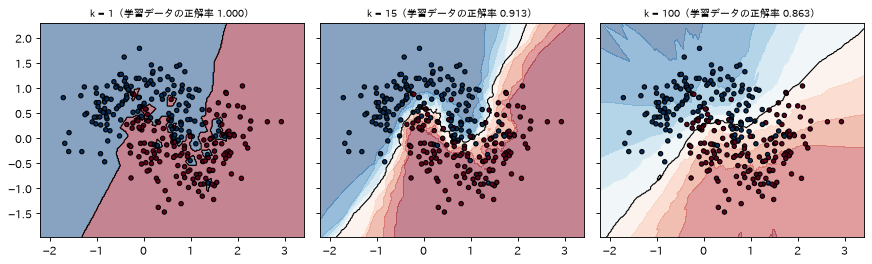

In [10]:
Xm, ym = make_moons(300, noise=0.35, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for ax, k in zip(axes, [1, 15, 100]):
    m = nbr.KNeighborsClassifier(n_neighbors=k).fit(Xm, ym)
    plot_boundary(ax, m, Xm, ym, f"k = {k}（学習データの正解率 {m.score(Xm, ym):.3f}）")
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- **$k = 1$**: 境界がギザギザで、ノイズの点 1 つ 1 つのまわりに「飛び地」ができています。学習データの正解率は 1.000（各点の最近傍は自分自身）ですが、これは**暗記**しているだけです。背景も 0 か 1 の 2 色しかありません（1 人に聞くので確率も 0 か 1）。
- **$k = 15$**: 境界がなめらかになり、三日月の形に沿っています。ガイドの「$k$ を大きくするとノイズの影響が抑えられる」の効果です。
- **$k = 100$**: 境界がさらになめらかになり、三日月の先端の細かい形を捉えられなくなっています。背景の色も中間（白っぽい）領域が広がります。これが「境界がはっきりしなくなる」です。

$k$ は、1.1 で見た正則化の強さ `alpha` と同じく、**モデルの複雑さのつまみ**です。ただし向きが逆で、$k$ が**小さい**ほど複雑（過学習しやすい）です。

### 🧪 やってみよう: 交差検証で $k$ を選ぶ

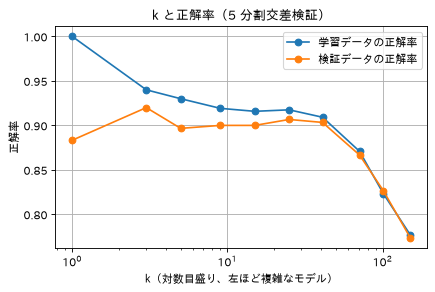

,学習データの正解率,検証データの正解率
k,,
1,1.0000,0.8833
3,0.9400,0.9200
5,0.9300,0.8967
9,0.9192,0.9000
15,0.9158,0.9000
25,0.9175,0.9067
41,0.9092,0.9033
71,0.8708,0.8667
101,0.8233,0.8267


In [11]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
rows = []
for k in [1, 3, 5, 9, 15, 25, 41, 71, 101, 151]:
    r = cross_validate(nbr.KNeighborsClassifier(n_neighbors=k), Xm, ym, cv=cv, return_train_score=True)
    rows.append({"k": k, "学習データの正解率": r["train_score"].mean(), "検証データの正解率": r["test_score"].mean()})
df_k = pd.DataFrame(rows).set_index("k")
df_k.plot(marker="o", logx=True); plt.xlabel("k（対数目盛り、左ほど複雑なモデル）"); plt.ylabel("正解率")
plt.title("k と正解率（5 分割交差検証）"); plt.show()
df_k

### 👀 結果の読み方

- $k = 1$ では学習データの正解率が 1.0 なのに、検証データでは最も低い部類です。**過学習**の典型です。
- $k$ を増やすと、学習と検証の差が縮まり、検証の正解率は $k = 3$〜$41$ あたりで高く（約 0.90〜0.92）なります。
- $k$ が大きすぎる（71 以上）と、学習・検証ともに下がります。三日月の形を捉えられない**未学習**です。

> 💡 **目安**: よく使われる出発点は $k = 5$（scikit-learn の既定値）や $\sqrt{n}$ 程度ですが、ガイドの言うとおり最適な $k$ はデータ次第なので、交差検証で選ぶのが確実です。2 クラス分類では、票が同数にならないよう奇数の $k$ を使うことがよくあります（次の ⚠️）。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: 票が同数になったとき（たとえば $k = 2$ で 1 票ずつ）、`KNeighborsClassifier` は**番号の小さいクラス**（`classes_` の先頭のほう）を選びます。

In [12]:
m = nbr.KNeighborsClassifier(n_neighbors=2).fit([[1.0], [-1.2]], [1, 0])
print("predict_proba:", m.predict_proba([[0.0]]), "→ predict:", m.predict([[0.0]]))

predict_proba: [[0.5 0.5]] → predict: [0]


👀 確率は 0.5 ずつで同点なのに、予測はクラス 0 です。実際には点 $[1.0]$（クラス 1）のほうが近いのに、`weights="uniform"` では距離を無視して 1 票ずつと数えるので、同点になり、先頭のクラス 0 が選ばれました。次の `weights="distance"` なら、近い点の票が重くなるので、こうした同点は起こりにくくなります。

### 📖 近傍の重み付け

基本の最近傍分類は**一様な重み**を使います。つまり、問い合わせた点に割り当てる値は、最近傍の単純な多数決で決まります。状況によっては、**近い近傍ほど大きく寄与する**ように重みを付けたほうがよいことがあります。これは引数 `weights` で指定します。

| `weights` | 重み |
|---|---|
| `"uniform"`（既定） | すべての近傍に同じ重み |
| `"distance"` | 問い合わせ点からの距離の**逆数**に比例する重み |
| 関数 | 距離の配列を受け取り、同じ形の重みの配列を返す、ユーザー定義の関数 |

#### 📈 学習したモデルを見る: `uniform` と `distance`

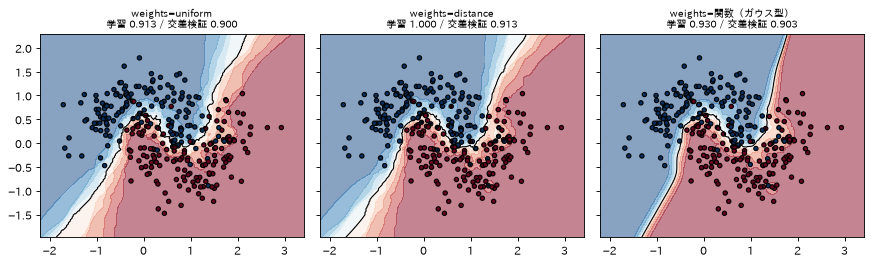

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
gauss = lambda d: np.exp(-(d / 0.3) ** 2)            # ユーザー定義の重み（ガウス型）
for ax, w in zip(axes, ["uniform", "distance", gauss]):
    m = nbr.KNeighborsClassifier(n_neighbors=15, weights=w).fit(Xm, ym)
    name = w if isinstance(w, str) else "関数（ガウス型）"
    cvs = cross_val_score(nbr.KNeighborsClassifier(n_neighbors=15, weights=w), Xm, ym, cv=cv).mean()
    plot_boundary(ax, m, Xm, ym, f"weights={name}\n学習 {m.score(Xm, ym):.3f} / 交差検証 {cvs:.3f}")
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- `"distance"`（中央）の境界は、見た目では `"uniform"`（左）とほとんど変わりません。それなのに、学習データの正解率は **1.000** になっています（理由は下の ⚠️）。
- ガウス型の重み（右）は、距離が離れると重みが急速に 0 に近づくので、データから離れた場所（左下や右上）では、一番近い数点だけで決まります。そのため背景の色が濃く（確率が 0 か 1 に近く）なり、境界の線も直線的になっています。
- 交差検証の正解率は、3 つの重み付けで大きくは変わりません。どれがよいかはデータ次第です。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: `weights="distance"` では、学習データの点そのものを予測すると、距離 0 の近傍（自分自身）の重みが無限大になり、**必ず自分のラベルを答えます**（scikit-learn は距離 0 の近傍だけで決める）。そのため、学習データの正解率は常に 1.0 になり、過学習の目安になりません。モデルの良し悪しは、必ず交差検証やテストデータで測りましょう。

### 📖 半径ベースの分類

データが一様にサンプリングされていない場合は、`RadiusNeighborsClassifier` による**半径ベース**の分類がよい選択になることがあります。ユーザーが固定の半径 $r$ を決めるので、まばらな場所の点ほど、分類に使う近傍の数が少なくなります。ただし、高次元の空間では、いわゆる**次元の呪い**のため、この方法はあまり効果的ではなくなります（下の 🧪 で確かめます）。

> 📚 **用語**: **次元の呪い（curse of dimensionality）** — 特徴の数（次元）が増えると、空間が急激に広くなり、データがまばらになって、「近い」「遠い」の区別がつきにくくなるなど、低次元での直感が通用しなくなる現象の総称。ベルマン（R. Bellman）が 1961 年ごろに名付けた。

#### 📈 半径の内側にいくつ近傍があるか

密な場所とまばらな場所があるデータで、各点の半径 0.5 の内側にある学習サンプルの数を色で表します。

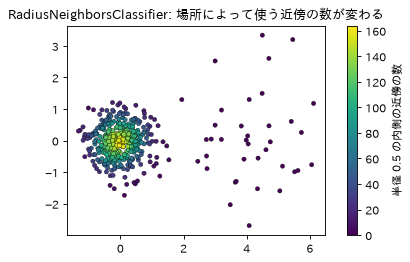

近傍の数: 密な場所の中央値 93.5 / まばらな場所の中央値 1.0 / 近傍が 0 個の点 12 個


,交差検証の正解率
KNeighborsClassifier(n_neighbors=15),0.9636
RadiusNeighborsClassifier(radius=0.5),0.9500
RadiusNeighborsClassifier(radius=1.0),0.8750


In [14]:
rs = np.random.RandomState(0)
X_dense = rs.randn(400, 2) * 0.5                        # 原点のまわりに密集
X_sparse = rs.randn(40, 2) * 1.5 + [4, 0]               # 右側にまばら
Xd = np.vstack([X_dense, X_sparse])
yd = np.r_[(X_dense.sum(1) > 0).astype(int), (X_sparse[:, 1] > 0).astype(int)]
rad = nbr.RadiusNeighborsClassifier(radius=0.5, outlier_label="most_frequent").fit(Xd, yd)
counts = np.array([len(ix) for ix in rad.radius_neighbors(Xd, return_distance=False)]) - 1   # 自分自身を除く
plt.figure(figsize=(7, 3.4))
sc = plt.scatter(Xd[:, 0], Xd[:, 1], c=counts, cmap="viridis", s=15, edgecolor="k", lw=0.3)
plt.colorbar(sc, label="半径 0.5 の内側の近傍の数"); plt.gca().set_aspect("equal")
plt.title("RadiusNeighborsClassifier: 場所によって使う近傍の数が変わる"); plt.grid(False); plt.show()
print("近傍の数: 密な場所の中央値", np.median(counts[:400]), "/ まばらな場所の中央値", np.median(counts[400:]),
      "/ 近傍が 0 個の点", (counts == 0).sum(), "個")
cvs = {name: cross_val_score(m, Xd, yd, cv=cv).mean() for name, m in [
    ("KNeighborsClassifier(n_neighbors=15)", nbr.KNeighborsClassifier(15)),
    ("RadiusNeighborsClassifier(radius=0.5)", nbr.RadiusNeighborsClassifier(0.5, outlier_label="most_frequent")),
    ("RadiusNeighborsClassifier(radius=1.0)", nbr.RadiusNeighborsClassifier(1.0, outlier_label="most_frequent"))]}
pd.Series(cvs, name="交差検証の正解率").to_frame()

### 👀 結果の読み方

- 密な場所（左）の点は、半径 0.5 の内側に 100 個前後の近傍を持ちますが、まばらな場所（右）の点は数個しかなく、0 個の点もあります。$k$ 近傍法なら、どちらの場所でも同じ $k$ 個を使い、まばらな場所では**遠くの点まで**近傍に含めてしまいます。半径ベースでは、「遠すぎる点は使わない」という考え方になります。
- ただし、このデータでの交差検証の正解率は、`KNeighborsClassifier` のほうが高くなりました。まばらな場所で近傍が少なすぎたり、0 個だったりするためです。半径ベースが有利になるのは、「遠くの点は当てにならない」という前提が成り立つデータです。**ガイドの「よい選択になることがある」は「常によい」ではない**ので、交差検証で比べるのが確実です。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: `RadiusNeighborsClassifier` は、半径の内側に学習サンプルが 1 つもない点を予測すると、既定では**エラー**になります。`outlier_label` に、そうした点に付けるラベル（`"most_frequent"` など）を指定しておく必要があります。

In [15]:
try:
    nbr.RadiusNeighborsClassifier(radius=0.5).fit(Xd, yd).predict([[10.0, 10.0]])
except ValueError as e:
    print("ValueError:", str(e)[:110], "...")
print("outlier_label='most_frequent' なら:", rad.predict([[10.0, 10.0]]))

ValueError: No neighbors found for test samples array([0]), you can try using larger radius, giving a label for outliers,  ...
outlier_label='most_frequent' なら: [0]


### 🧪 やってみよう: 次元の呪いを確かめる

#### ① 高次元では「最も近い点」と「最も遠い点」の距離の差がなくなる

$[0, 1]^D$ の一様乱数の点 1,000 個について、ある点から見た「最も近い点までの距離 ÷ 最も遠い点までの距離」を、次元 $D$ を変えて計算します。

In [16]:
rs = np.random.RandomState(0)
rows = []
for D in [1, 2, 10, 100, 1000]:
    P = rs.rand(1000, D); Q = rs.rand(20, D)
    d = np.sqrt(((Q[:, None, :] - P[None, :, :]) ** 2).sum(-1))
    rows.append({"次元 D": D, "最近傍の距離 ÷ 最遠点の距離（20 点の平均）": (d.min(1) / d.max(1)).mean()})
pd.DataFrame(rows).set_index("次元 D")

,最近傍の距離 ÷ 最遠点の距離（20 点の平均）
次元 D,
1,0.0009
2,0.0128
10,0.2643
100,0.6933
1000,0.8906


👀 2 次元では、最も近い点は最も遠い点の 1% ほどの距離にありますが、1,000 次元では、最も近い点でも最も遠い点の約 9 割の距離にあります。**どの点もだいたい同じくらい遠い**ので、「近い点を探す」こと自体の意味が薄れます。半径ベースの方法では、半径をどう選んでも「ほとんど 0 個」か「ほとんど全部」になりやすくなります。

#### ② 関係のない特徴を足すと、k 近傍法の性能が落ちる

三日月のデータ（2 特徴）に、ラベルと関係のない一様乱数の特徴を足していきます。

In [17]:
rows = []
for extra in [0, 2, 10, 50, 200]:
    scores = []
    for seed in range(5):                                # 足す乱数を 5 通り変えて平均する
        noise_feats = np.random.RandomState(seed).uniform(-1, 1, (len(Xm), extra))
        Xe = np.hstack([Xm, noise_feats])
        scores.append(cross_val_score(nbr.KNeighborsClassifier(15), Xe, ym, cv=cv).mean())
    rows.append({"足した無関係な特徴の数": extra, "交差検証の正解率（k=15, 5 通りの平均）": np.mean(scores),
                 "5 通りの最小": np.min(scores), "5 通りの最大": np.max(scores)})
pd.DataFrame(rows).set_index("足した無関係な特徴の数")

,"交差検証の正解率（k=15, 5 通りの平均）",5 通りの最小,5 通りの最大
足した無関係な特徴の数,,,
0,0.9000,0.9000,0.9000
2,0.8760,0.8600,0.8867
10,0.7967,0.7767,0.8133
50,0.7807,0.7400,0.8267
200,0.6987,0.6800,0.7267


👀 無関係な特徴が増えるほど、正解率が下がっていきます。距離はすべての特徴の差を足し合わせるので、ラベルと関係のない特徴の差が「近さ」をかき乱すからです。最近傍法は**特徴の選び方に敏感**です。特徴選択（1.13 節）や次元削減（PCA、2/2 の NCA）と組み合わせる理由がここにあります。

### 🧪 やってみよう: スケーリングの効果（ガイドに書かれていない ⚠️）

最近傍法は距離だけで決まるので、**特徴のスケール（単位）**の影響を直接受けます。ワインのデータ（13 特徴）は、特徴ごとに値の大きさがまったく違います。

In [18]:
Xw, yw = load_wine(return_X_y=True)
print("各特徴の標準偏差:", np.round(Xw.std(0), 2))
res = {"スケーリングなし": cross_val_score(nbr.KNeighborsClassifier(), Xw, yw, cv=cv).mean(),
       "StandardScaler + k 近傍法": cross_val_score(make_pipeline(StandardScaler(), nbr.KNeighborsClassifier()), Xw, yw, cv=cv).mean()}
pd.Series(res, name="交差検証の正解率").to_frame()

各特徴の標準偏差: [  0.81   1.11   0.27   3.33  14.24   0.62   1.     0.12   0.57   2.31
   0.23   0.71 314.02]


,交差検証の正解率
スケーリングなし,0.6633
StandardScaler + k 近傍法,0.9608


👀 最後の特徴（プロリン）の標準偏差は約 300 で、ほかの特徴（0.1〜15 程度）よりはるかに大きいので、スケーリングしないと、距離はほとんどこの 1 つの特徴だけで決まってしまいます。標準化すると、正解率が大きく上がりました。たとえ話の「㎡と築年数を同じ物差しで比べてしまう」問題です。**最近傍法を使うときは、まず標準化**と覚えておきましょう。

---
## 3. 最近傍法による回帰（1.6.3 Nearest Neighbors Regression）

### 📖 ガイドの解説

近傍に基づく回帰は、データのラベルが離散ではなく連続の変数の場合に使えます。問い合わせた点に割り当てるラベルは、その最近傍のラベルの**平均**で計算します。

scikit-learn には 2 種類の近傍の回帰器があります。`KNeighborsRegressor` は各問い合わせ点の $k$ 個の最近傍（$k$ はユーザーが決める整数）、`RadiusNeighborsRegressor` は問い合わせ点から固定の半径 $r$（ユーザーが決める小数）の内側の近傍に基づいて学習します。

基本の最近傍回帰は一様な重みを使います。つまり、局所的な近傍のそれぞれの点が、問い合わせ点の予測に均等に寄与します。状況によっては、近い点が遠い点より大きく寄与するように重みを付けると有利なことがあります。これは引数 `weights` で指定します。既定値 `weights='uniform'` はすべての点に同じ重みを、`weights='distance'` は問い合わせ点からの距離の逆数に比例する重みを割り当てます。距離のユーザー定義の関数を与えて、重みを計算させることもできます。

### 🔢 数式を読む: 近傍の平均と重み付き平均

$$\hat{y}(x) = \frac{\sum_{i \in N_k(x)} w_i \, y_i}{\sum_{i \in N_k(x)} w_i}$$

| 記号 | 意味 |
|---|---|
| $y_i$ | 近傍 $i$ の目的変数の値 |
| $w_i$ | 近傍 $i$ の重み（`uniform` なら 1、`distance` なら $1 / d(x, x_i)$） |

**日本語で読むと**: 近い $k$ 件の値を、重みを付けて平均したものを予測にする。`uniform` なら単純な平均。

> 📐 **もっと詳しく**: [数式編「近傍の平均と重み付き平均」](./math/06_neighbors_1_knn_math.md#mean)（数値の例・導き方つき）

#### 📈 学習したモデルを見る: 予測の曲線（ガイドの例の再現）

ガイドの例（Nearest Neighbors regression）と同じく、ノイズを加えた正弦波のデータ 40 点で、$k = 5$ の `uniform` と `distance` を比べます。

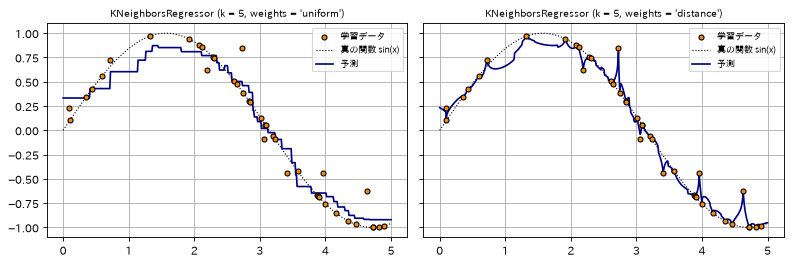

In [19]:
rs = np.random.RandomState(0)
Xs = np.sort(5 * rs.rand(40, 1), axis=0)
ys = np.sin(Xs).ravel()
ys[::5] += 1 * (0.5 - rs.rand(8))                  # 5 点に 1 点、ノイズを加える
T = np.linspace(0, 5, 500)[:, None]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, w in zip(axes, ["uniform", "distance"]):
    m = nbr.KNeighborsRegressor(n_neighbors=5, weights=w).fit(Xs, ys)
    ax.scatter(Xs, ys, c="darkorange", edgecolor="k", s=20, label="学習データ", zorder=3)
    ax.plot(T, np.sin(T), "k:", lw=1, label="真の関数 sin(x)")
    ax.plot(T, m.predict(T), c="navy", lw=1.5, label="予測")
    ax.set_title(f"KNeighborsRegressor (k = 5, weights = '{w}')", fontsize=9); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- `uniform`（左）の予測は、**階段状**の曲線です。問い合わせ点を左から右へ動かしても、近傍の 5 点の組が変わるまでは予測が変わらず、組が変わった瞬間に段差ができるからです。ノイズの点の影響も、5 点の平均でならされています。
- `distance`（右）の予測は、**学習データの点をすべて通ります**（距離 0 の点の重みが無限大になるため）。点と点の間は、近い点ほど重く見る補間になり、ノイズを加えた点にも引き寄せられています。
- どちらも、学習データの端より外側（図の左端の $x \approx 0$ 付近や右端）では、端の近傍の値を使い続けるので、**横ばい（外挿できない）**になります。左の図の左端で、予測の線が水平になっているのがその例です。線形モデルとの大きな違いです。

### 🧪 やってみよう: `RadiusNeighborsRegressor` と「近傍がない」場所

出た警告: {'One or more samples have no neighbors within specified radius; predicting NaN.'}
NaN になった問い合わせ点の割合: 0.17


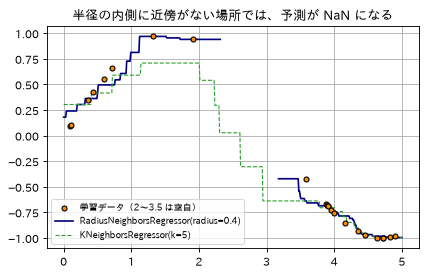

In [20]:
Xgap = np.r_[Xs[Xs.ravel() < 2], Xs[Xs.ravel() > 3.5]].reshape(-1, 1)      # 2〜3.5 にデータがない
ygap = np.sin(Xgap).ravel()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    pred = nbr.RadiusNeighborsRegressor(radius=0.4).fit(Xgap, ygap).predict(T)
print("出た警告:", {str(w.message) for w in caught})
print("NaN になった問い合わせ点の割合:", np.isnan(pred).mean().round(3))
plt.scatter(Xgap, ygap, c="darkorange", edgecolor="k", s=20, label="学習データ（2〜3.5 は空白）", zorder=3)
plt.plot(T, pred, c="navy", lw=1.5, label="RadiusNeighborsRegressor(radius=0.4)")
plt.plot(T, nbr.KNeighborsRegressor(5).fit(Xgap, ygap).predict(T), c="tab:green", lw=1, ls="--", label="KNeighborsRegressor(k=5)")
plt.legend(fontsize=8); plt.title("半径の内側に近傍がない場所では、予測が NaN になる"); plt.show()

### 👀 結果の読み方

- `RadiusNeighborsRegressor`（青）は、データのない区間（2〜3.5 の中央付近）で線が**途切れて**います。半径 0.4 の内側に近傍がないので、予測が NaN（数値でない）になり、警告が出ます。分類器のようにエラーにはなりませんが、**NaN がそのまま後の処理に流れる**ので注意が必要です。
- `KNeighborsRegressor`（緑の破線）は、どこでも必ず 5 個の近傍を使うので、空白の区間でも予測を返します。ただしその値は、空白の両側の離れた点を混ぜた平均で、正しいかどうかは（データがないので）分かりません。また、近傍を 5 個に固定しているので、データのある場所でも、青の線より粗い（実際の点からずれた）階段になっています。「答えられない」ことを NaN で知らせる半径ベースと、「遠くても何か答える」$k$ 近傍法の、どちらが望ましいかは用途によります。

### 📖 多出力の回帰

多出力の最近傍回帰の使い方は、ガイドの例 *Face completion with a multi-output estimators* で示されています。この例では、入力 `X` は顔の画像の**上半分**の画素、出力 `Y` は**下半分**の画素です。

💡 最近傍法は、近傍の $y$ を平均するだけなので、$y$ が 1 つの数でもベクトル（多出力）でも、まったく同じ仕組みで動きます。顔の例では「上半分が似ている顔を探して、その下半分を平均する」ことで、顔の下半分を補完しています。小さな例で確かめます。

In [21]:
Y2 = np.c_[np.sin(Xs).ravel(), np.cos(Xs).ravel()]           # 出力が 2 つ
m2 = nbr.KNeighborsRegressor(n_neighbors=3).fit(Xs, Y2)
print("予測の形:", m2.predict(T).shape, "（500 点 × 2 出力）")
dist, idx = m2.kneighbors([[2.5]])
print("x = 2.5 の予測        :", m2.predict([[2.5]]).round(4))
print("近傍 3 点の Y の平均   :", Y2[idx[0]].mean(0).round(4))

予測の形: (500, 2) （500 点 × 2 出力）
x = 2.5 の予測        : [[ 0.5751 -0.8041]]
近傍 3 点の Y の平均   : [ 0.5751 -0.8041]


### 🏢 実務での選ばれ方: k 近傍法（`KNeighborsClassifier` / `KNeighborsRegressor`）

- ✅ **特に選ばれる場面**: 境界がとても不規則で、データが数万件くらいまでのとき。手早く試すベースライン。データを足すだけで更新できる（学習し直しがいらない）。予測の根拠を「この 5 件に似ているから」と見せたいとき。欠損値の補完（`KNNImputer`）や異常検知（近くに仲間がいない点、`LocalOutlierFactor`）の部品として。
- ❌ **選ばれない場面**: データが大きい（予測のたびに近傍を探すので遅く、データを全部保存する）。特徴が多い・関係のない特徴が多い（次元の呪い）。カテゴリと数値が混ざった表形式のデータで精度を競う → 勾配ブースティング。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: `make_pipeline(StandardScaler(), KNeighborsClassifier())` + 交差検証で `n_neighbors` を選ぶのが基本形です。次元が高いときは、PCA や NCA（2/2）で次元を減らしてから使います。実務の分類器としては勾配ブースティングやロジスティック回帰が選ばれることが多く、k 近傍法は推薦・類似検索・補完・異常検知などの「部品」としてよく使われます。

👀 2 つの出力のどちらも、同じ 3 つの近傍の値の平均になっています。出力ごとに別のモデルを作る必要はありません。

---
## 4. まとめ

### 最近傍法のクラス（このノートの範囲）

| クラス | 用途 | 主な引数 | 注意 |
|---|---|---|---|
| `NearestNeighbors` | 近傍の探索（教師なし） | `n_neighbors`, `radius`, `algorithm`, `metric` | 自分を除くなら `kneighbors()` を引数なしで |
| `KNeighborsClassifier` | 分類 | `n_neighbors`（既定 5）, `weights` | 同票は番号の小さいクラス |
| `RadiusNeighborsClassifier` | 分類 | `radius`, `weights`, `outlier_label` | 近傍なしはエラー → `outlier_label` |
| `KNeighborsRegressor` | 回帰 | `n_neighbors`, `weights` | 範囲外は横ばい |
| `RadiusNeighborsRegressor` | 回帰 | `radius`, `weights` | 近傍なしは NaN（警告） |
| `KDTree` / `BallTree` | 探索の索引を直接使う | `leaf_size`, `metric` | 2/2 で詳しく |

### 引数の効き方

| 引数 | 小さく / 単純にすると | 大きく / 複雑にすると |
|---|---|---|
| `n_neighbors`（$k$） | 境界がギザギザ、過学習（$k = 1$ で学習データは必ず正解） | 境界がなめらか、大きすぎると未学習 |
| `radius`（$r$） | 近傍が 0 個の点が増える | 遠くの点まで混ざる |
| `weights` | `"uniform"`: 単純な多数決・平均（階段状） | `"distance"`: 学習データの点を必ず再現（学習データの正解率は常に 1） |

### 覚えておきたい 3 つのこと

1. **学習 = データを覚える、予測 = 近いものを探して多数決・平均**。中身は数行で書けるほど単純で、ノンパラメトリックなので不規則な境界も表現できる。
2. **$k$ は複雑さのつまみ**（小さいほど複雑）。交差検証で選ぶ。`weights="distance"` では学習データの正解率が当てにならない。
3. **距離がすべて**。スケーリング（標準化）は必須で、無関係な特徴や高次元（次元の呪い）に弱い。

### 🧩 ドメインモデルの視点

- 最近傍法のモデルは、「**学習データの索引（リポジトリ）**」と「**問い合わせ（クエリ）の方針**」に分けて考えると分かりやすくなります。`fit` は索引を作るだけで、`predict` は「この点に近いものを探せ」というクエリを索引に投げ、返ってきた近傍を多数決・平均する処理です。TypeScript / Java で書くなら、`NeighborIndex`（`KDTree` / `BallTree` / 総当たり）というインターフェースと、それを使う `KNeighborsClassifier` を分ける設計で、実際に scikit-learn もそうなっています（`algorithm` 引数で索引の実装を差し替える = **ストラテジーパターン**）。
- 「距離（`metric`）」「何件見るか（`n_neighbors` / `radius`）」「票の重み（`weights`）」は、互いに独立した**値オブジェクト**のような設定で、組み合わせでモデルが決まります。`weights` に関数を渡せるのは、「重みの計算」という振る舞いを外から注入できる設計です。
- 線形モデルの「モデル = 係数のベクトル」に対して、最近傍法の「モデル = 学習データそのもの」です。保存すればデータ全部が保存され、予測のたびに索引を引くので、**モデルの大きさと予測の時間がデータ量とともに増える**ことは、設計上のトレードオフとして意識しておきましょう。

### ✅ 確認クイズ

**Q1.** `KNeighborsClassifier(n_neighbors=1)` の学習データの正解率が 1.0 でした。このモデルはよいモデルと言えますか。

<details><summary>答え</summary>

言えません。$k = 1$ では、学習データの各点の最近傍は自分自身なので、学習データの正解率は（同じ座標で違うラベルの点がない限り）必ず 1.0 になります。性能は交差検証やテストデータで測る必要があります。
</details>

**Q2.** $k = 5$ の近傍のラベルが [A, A, B, B, B] で、それぞれの距離が [0.1, 0.2, 1.0, 1.0, 1.0] のとき、`weights="uniform"` と `weights="distance"` の予測はそれぞれ何ですか。

<details><summary>答え</summary>

`uniform`: A が 2 票、B が 3 票なので **B**。`distance`: A の票は $1/0.1 + 1/0.2 = 15$、B の票は $1 + 1 + 1 = 3$ なので **A**。
</details>

**Q3.** k 近傍法の前に `StandardScaler` を入れるのはなぜですか。

<details><summary>答え</summary>

距離はすべての特徴の差を足し合わせて計算するので、値の大きい（単位の大きい）特徴が距離をほとんど決めてしまうからです。標準化して特徴の大きさをそろえることで、すべての特徴が距離に公平に効くようになります。
</details>

**Q4.** `RadiusNeighborsRegressor` で、半径の内側に学習サンプルがない点を予測すると、どうなりますか。分類器の `RadiusNeighborsClassifier` ではどうですか。

<details><summary>答え</summary>

回帰器は警告を出して NaN を返します。分類器は既定ではエラー（`ValueError`）になり、`outlier_label` を指定すると、そのラベルを返します。
</details>

**Q5.** 特徴が 1,000 個ある高次元のデータで、最近傍法がうまくいかないことがあるのはなぜですか。

<details><summary>答え</summary>

次元の呪いのため、高次元ではどの点もだいたい同じくらい遠くなり（最近傍と最遠点の距離の比が 1 に近づく）、「近い点」を探すことの意味が薄れるからです。ラベルと関係のない特徴が距離をかき乱すことも原因です。特徴選択や次元削減と組み合わせると改善することがあります。
</details>

---
**前の節**: [1.5 確率的勾配降下法](./05_sgd.ipynb) ・ **次のノート**: [1.6 最近傍法（2/2）探索アルゴリズム・最近傍重心・NCA](./06_neighbors_2_algorithms_nca.ipynb)